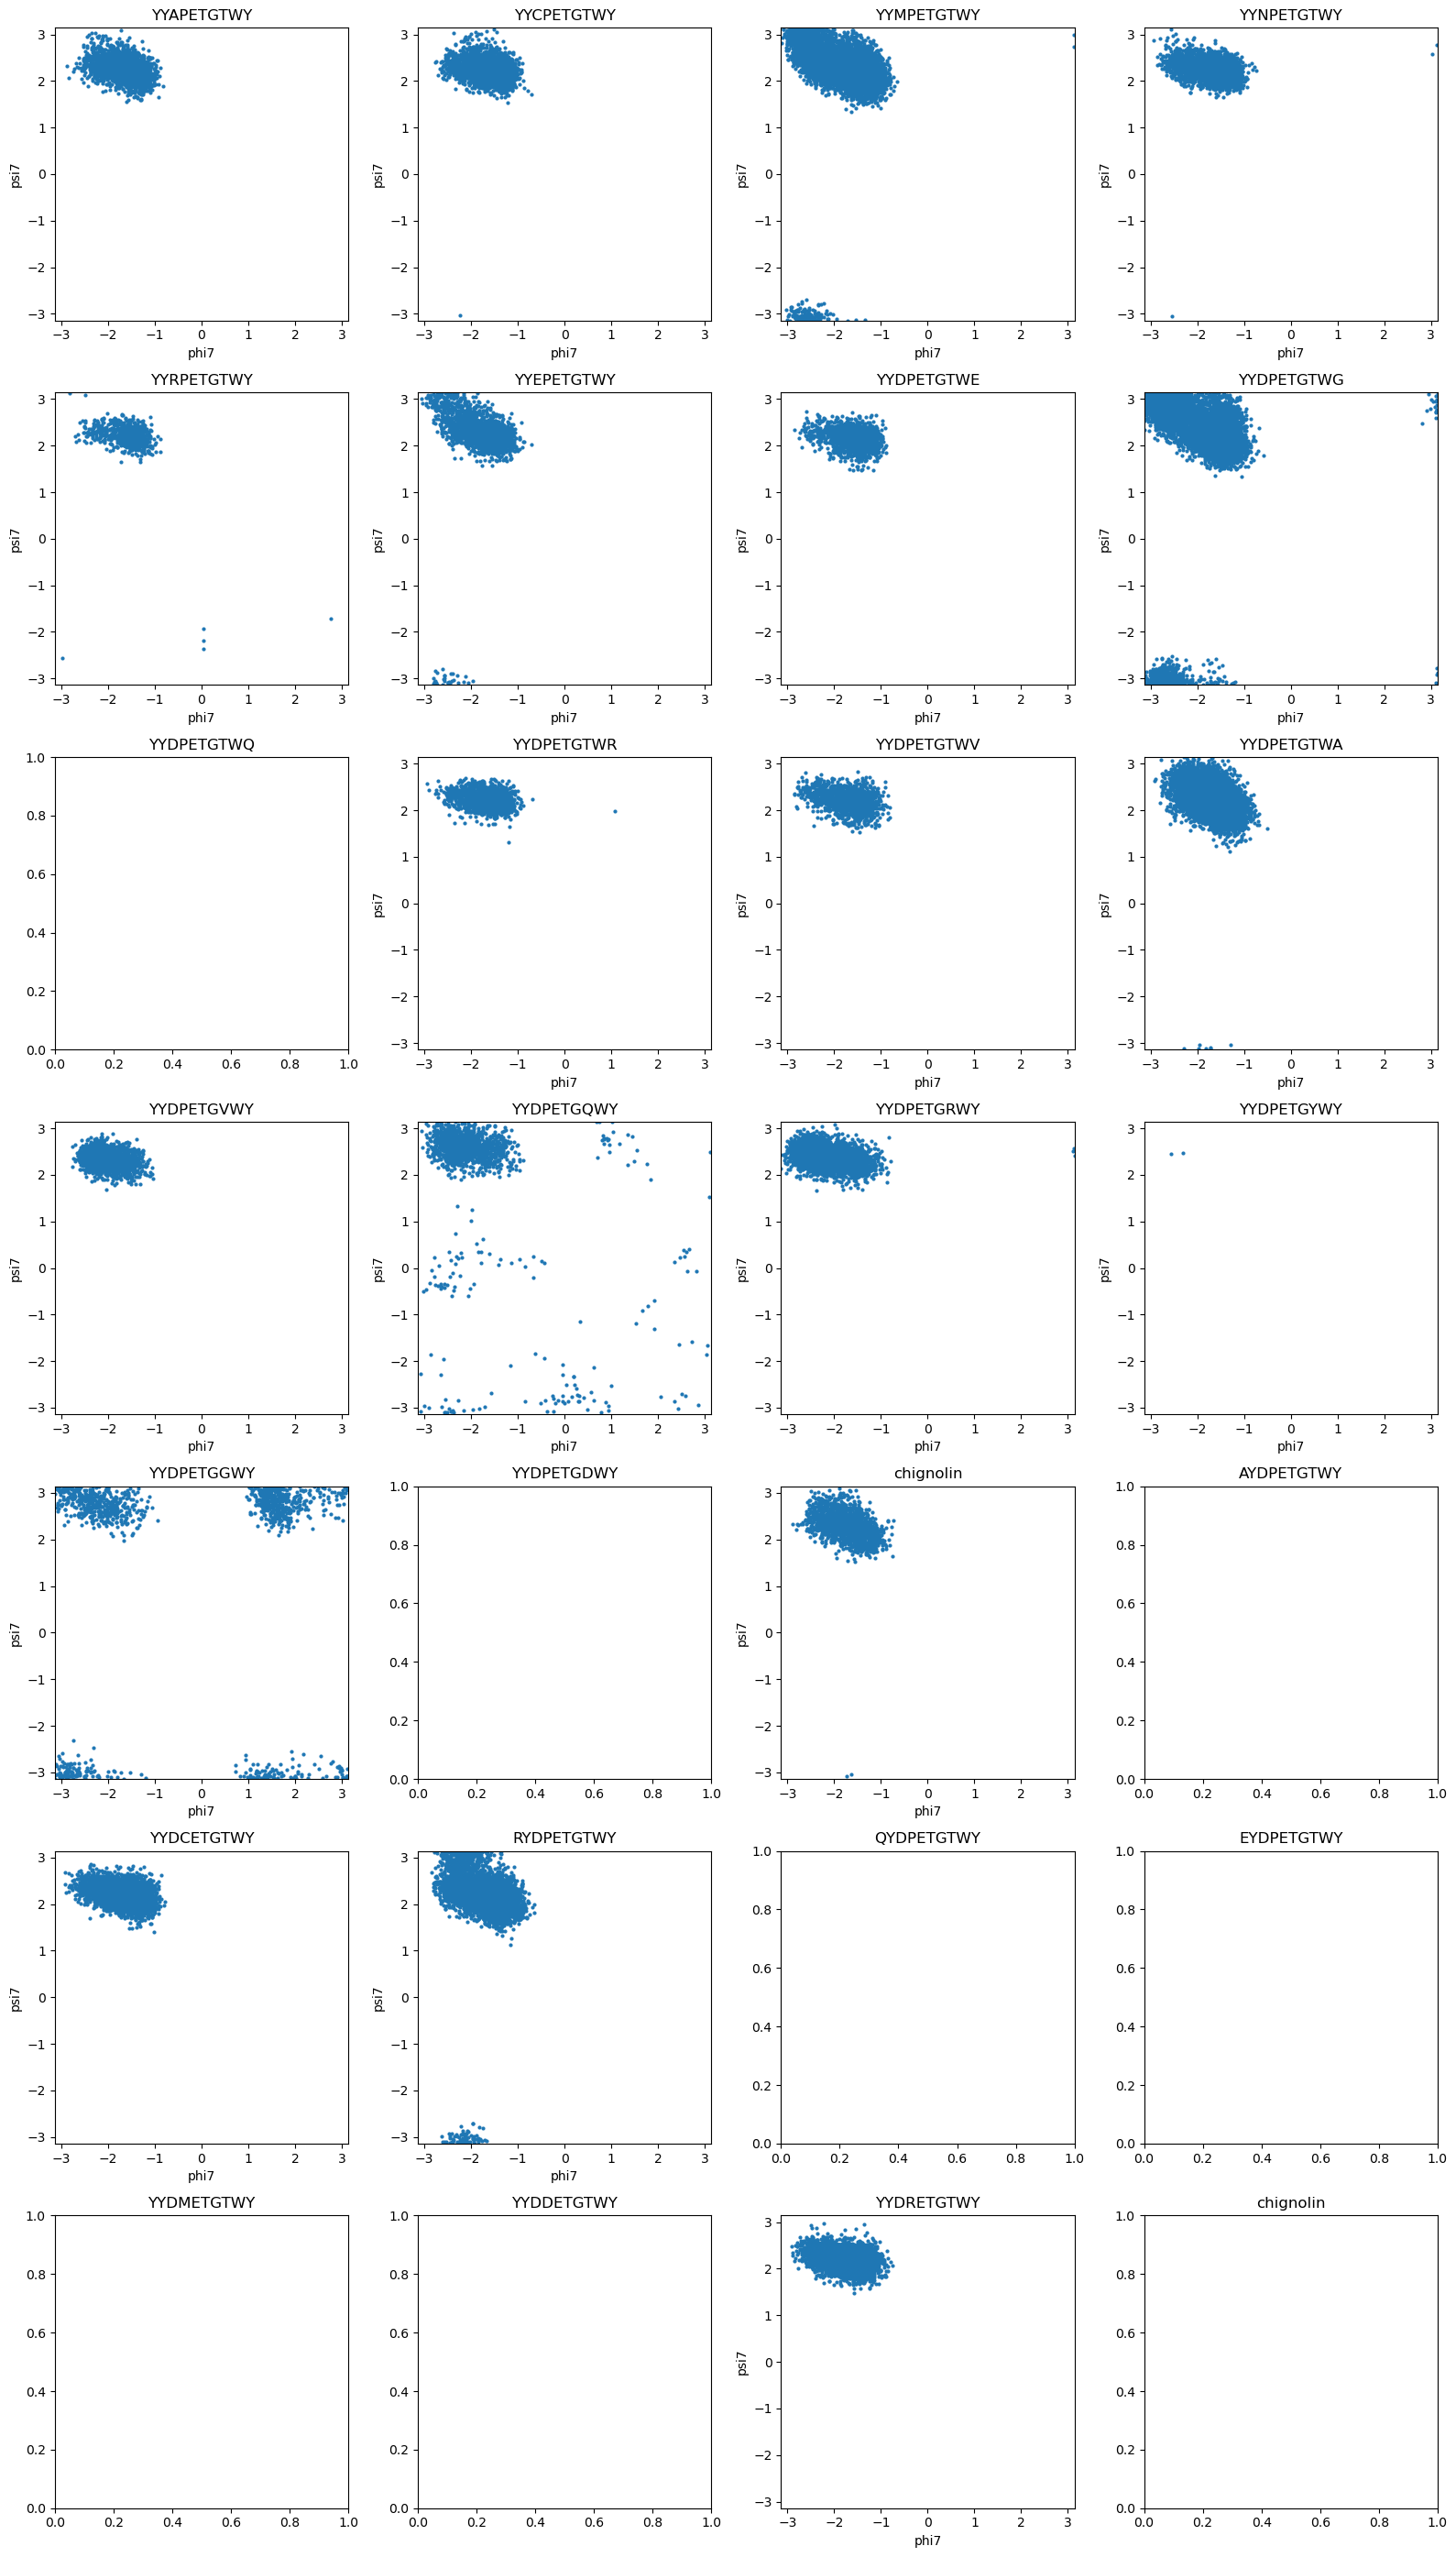

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.consts import mutation_map

proteins = list(mutation_map.keys()) + ['chignolin      ']

def read_colvar_with_fields(path: Path) -> pd.DataFrame:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    parts = header.strip().split()
    if len(parts) < 3 or parts[1] != "FIELDS":
        raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

n = len(proteins)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))

for ax, protein in zip(axes.flat, proteins):
    ax.set_title(protein.strip())

    colvar = Path(f"../data/{protein}/output/run_000/COLVAR_000")
    try:
        df = read_colvar_with_fields(colvar)
        # df = df[(df["rmsd"] < 0.1)]
    except FileNotFoundError:
        continue

    ax.scatter(df["phi7"], df["psi7"], s=4)
    ax.set_xlabel("phi7")
    ax.set_ylabel("psi7")
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)

plt.tight_layout()
plt.show()
